### Plotting them in same plot

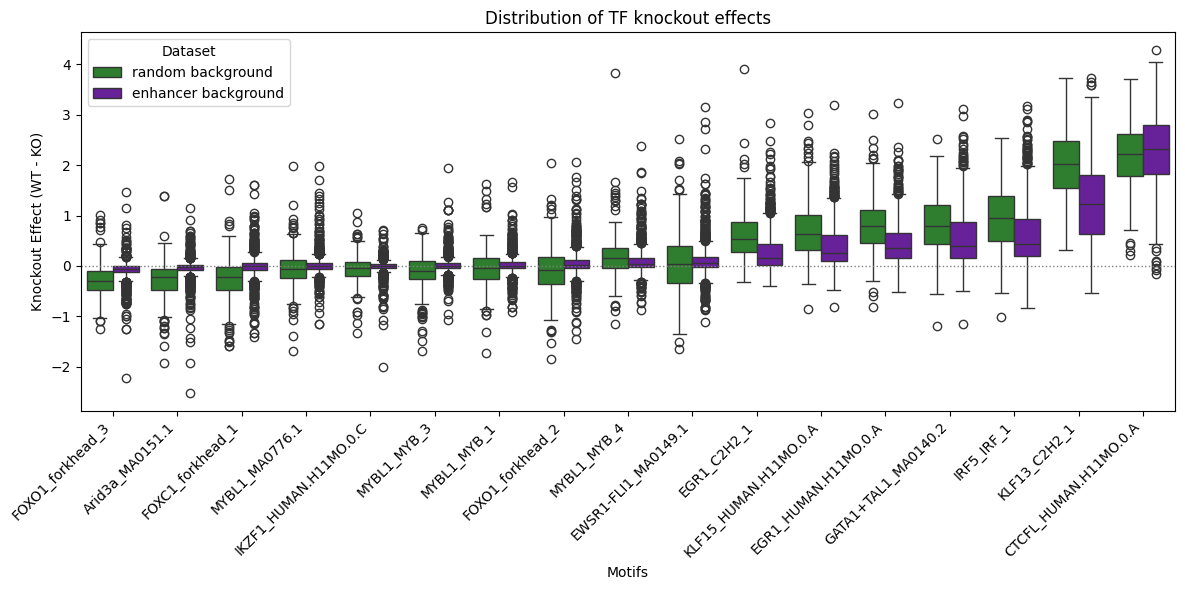

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the first dataset (already processed)
df1 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/4-range/human/predicted_human_tfs.csv")
df1_alt = df1[df1["motif_name"].str.endswith("_alt")].copy()
df1_ref = df1[~df1["motif_name"].str.endswith("_alt")].copy()
df1_alt["base_motif"] = df1_alt["motif_name"].str.replace("_alt", "", regex=False)
df1_ref["base_motif"] = df1_ref["motif_name"]

merged1 = pd.merge(
    df1_ref,
    df1_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)
merged1["variant_effect"] = merged1["predictions_ref"] - merged1["predictions_alt"]
merged1 = merged1[~merged1['base_motif'].str.contains("MOUSE", case=False, na=False)]
merged1["dataset"] = "random background"

# Load the second dataset (enhancer)
df2 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/4-range/human/predicted_human_tfs_enhancer.csv", sep="\t")
df2_alt = df2[df2["motif_name"].str.endswith("_alt")].copy()
df2_ref = df2[~df2["motif_name"].str.endswith("_alt")].copy()
df2_alt["base_motif"] = df2_alt["motif_name"].str.replace("_alt", "", regex=False)
df2_ref["base_motif"] = df2_ref["motif_name"]

merged2 = pd.merge(
    df2_ref,
    df2_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)
merged2["variant_effect"] = merged2["predictions_ref"] - merged2["predictions_alt"]
merged2 = merged2[~merged2['base_motif'].str.contains("MOUSE", case=False, na=False)]
merged2["dataset"] = "enhancer background"

# Combine the two
combined = pd.concat([merged1, merged2], axis=0, ignore_index=True)

# Optional: define order by median across both datasets
order = (
    combined.groupby("base_motif")["variant_effect"]
    .median()
    .sort_values()
    .index.tolist()
)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=combined,
    x="base_motif",
    y="variant_effect",
    hue="dataset",          # Color by dataset
    order=order,
    palette={"random background": "#228B22", "enhancer background": "#6A0DAD"}
)

plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Knockout Effect (WT - KO)")
plt.xlabel("Motifs")
plt.title("Distribution of TF knockout effects")
plt.legend(title="Dataset")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/4-range/human/distribution_combined.svg", format="svg")
plt.show()
